# Proyek Analisis Data: Brazilian E-Commerce Public Dataset by Olist
- **Nama:** Peter Taniwan
- **Email:** CDCC011D6Y2148@student.devacademy.id
- **ID Dicoding:** petertan

## Menentukan Pertanyaan Bisnis

**SMART Question** digunakan sebagai panduan untuk menyusun pertanyaan bisnis supaya analisis lebih terarah. Pada proyek ini, pertanyaan dibuat dengan berfokus pada lima aspek berikut.

- **Specific:** pertanyaan berfokus pada topik tertentu, yaitu tren penjualan dan segmentasi pelanggan Olist.
- **Measurable:** hasil analisis dapat dihitung dengan jumlah pesanan, total pendapatan, recency, frequency, dan monetary.
- **Action-Oriented:** hasilnya dapat digunakan dalam menentukan periode penjualan terbaik dan segmen pelanggan prioritas.
- **Relevant:** pertanyaan relevan dengan konteks bisnis e-commerce, terutama terkait penjualan dan perilaku pelanggan.
- **Time-bound:** analisis dibatasi pada transaksi berstatus `delivered` selama periode Oktober 2016 sampai Agustus 2018.

**Contoh penerapan SMART pada proyek ini**

Pertanyaan bisnis tidak hanya bertanya secara umum mengenai performa toko, tetapi diarahkan juga pada periode, metrik, dan tujuan analisis yang jelas. Oleh karena itu, hasil EDA dan visualisasi bisa langsung menjawab kebutuhan bisnis.

- **Pertanyaan 1:** Bagaimana tren performa penjualan Olist dari bulan ke bulan berdasarkan jumlah pesanan dan total pendapatan pada transaksi berstatus `delivered` selama periode Oktober 2016-Agustus 2018, lalu pada bulan apa penjualan tertinggi terjadi?
- **Pertanyaan 2:** Bagaimana segmentasi pelanggan Olist berdasarkan perilaku belanjanya menggunakan RFM analysis pada transaksi berstatus `delivered` selama periode Oktober 2016-Agustus 2018, lalu segmen pelanggan mana yang paling berharga berdasarkan rata-rata monetary?

## Import Semua Packages/Library yang Digunakan

In [4]:
%matplotlib inline

import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9

print("Library berhasil diimport dan siap digunakan.")


Library berhasil diimport dan siap digunakan.


## Data Wrangling

### Gathering Data

#### Load dataset utama yang dibutuhkan

In [5]:
data_dir = Path("data")

customers_df = pd.read_csv(data_dir / "customers_dataset.csv")
orders_df = pd.read_csv(data_dir / "orders_dataset.csv")
payments_df = pd.read_csv(data_dir / "order_payments_dataset.csv")

print("Ukuran customers_df:", customers_df.shape)
print("Ukuran orders_df:", orders_df.shape)
print("Ukuran payments_df:", payments_df.shape)

display(customers_df.head())
display(orders_df.head())
display(payments_df.head())


Ukuran customers_df: (99441, 5)
Ukuran orders_df: (99441, 8)
Ukuran payments_df: (103886, 5)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


**Insight:**
- Dataset utama yang digunakan ada 3 yaitu `customers_dataset.csv`, `orders_dataset.csv`, dan `order_payments_dataset.csv`.
- Dataset tersebut telah cukup dalam menjawab pertanyaan bisnis sebab memuat informasi pelanggan, waktu pembelian, status pesanan, metode pembayaran, dan nilai transaksi.
- Pada tahap ini, data masih berbentuk mentah sehingga perlu diperiksa kualitasnya sebelum dianalisis lebih lanjut.

### Assessing Data

#### Identifying data quality problem

In [35]:
datasets = {
    "customers_df": customers_df,
    "orders_df": orders_df,
    "payments_df": payments_df
}

for name, df in datasets.items():
    print(f"\nInformasi {name}")
    df.info()
    print("Duplicate values:", df.duplicated().sum())
    print("Missing values per kolom:")
    display(df.isna().sum())


Informasi customers_df
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 11.0 MB
Duplicate values: 0
Missing values per kolom:


customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


Informasi orders_df
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 21.9 MB
Duplicate values: 0
Missing values per kolom:


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


Informasi payments_df
<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 8.1 MB
Duplicate values: 0
Missing values per kolom:


order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [7]:
print("Distribusi status pesanan:")
display(orders_df["order_status"].value_counts())

print("Distribusi tipe pembayaran:")
display(payments_df["payment_type"].value_counts())

Distribusi status pesanan:


order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Distribusi tipe pembayaran:


payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

**Steps to Take:**
- Mengubah kolom tanggal pada dataset orders ke tipe data `datetime`.
- Menghapus duplikasi data apabila ditemukan pada dataset yang digunakan.
- Meringkas data pembayaran ke level `order_id` supaya nilai revenue tidak terhitung ganda.
- Memilih transaksi dengan status `delivered` karena merupakan pesanan yang sudah selesai.
- Membatasi periode analisis pada Oktober 2016 sampai Agustus 2018 sesuai pertanyaan bisnis.
- Menghapus baris tanpa nilai pembayaran karena tidak dapat digunakan dalam analisis pendapatan dan RFM.

**Insight:**
- Kolom tanggal pada data pesanan perlu perubahan tipe data supaya dapat digunakan untuk analisis berbasis waktu.
- Data pembayaran memiliki lebih dari satu baris untuk satu order, sehingga perlu diagregasi sebelum digabungkan.
- Status pesanan perlu diperhatikan karena analisis penjualan akan lebih konsisten apabila hanya menggunakan pesanan yang sudah selesai (`delivered`).

### Cleaning Data

#### Fixing data type, duplicate data, payment aggregation, and period filtering

In [8]:
# Membuat salinan data agar data mentah tetap aman
orders_clean_df = orders_df.copy()
customers_clean_df = customers_df.copy()
payments_clean_df = payments_df.copy()

# Mengubah kolom tanggal menjadi datetime
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in date_columns:
    orders_clean_df[column] = pd.to_datetime(orders_clean_df[column])

# Menghapus duplikasi jika ditemukan
orders_clean_df = orders_clean_df.drop_duplicates()
customers_clean_df = customers_clean_df.drop_duplicates()
payments_clean_df = payments_clean_df.drop_duplicates()

# Meringkas pembayaran per order agar revenue tidak terhitung ganda
payment_per_order_df = payments_clean_df.groupby("order_id", as_index=False).agg({
    "payment_value": "sum",
    "payment_installments": "max",
    "payment_type": lambda x: x.mode()[0]
})

# Menggabungkan data pesanan, pelanggan, dan pembayaran
main_df = orders_clean_df.merge(customers_clean_df, on="customer_id", how="left")
main_df = main_df.merge(payment_per_order_df, on="order_id", how="left")

# Memilih transaksi delivered pada periode Oktober 2016 sampai Agustus 2018
main_df = main_df[
    (main_df["order_status"] == "delivered") &
    (main_df["order_purchase_timestamp"] >= "2016-10-01") &
    (main_df["order_purchase_timestamp"] < "2018-09-01")
].copy()

# Menghapus baris tanpa nilai pembayaran karena tidak dapat digunakan untuk revenue/RFM
main_df = main_df.dropna(subset=["payment_value"])

# Membuat fitur waktu sederhana untuk analisis
main_df["order_date"] = main_df["order_purchase_timestamp"].dt.date
main_df["order_month"] = main_df["order_purchase_timestamp"].dt.strftime("%Y-%m")
main_df["order_month_date"] = main_df["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()
main_df["order_year"] = main_df["order_purchase_timestamp"].dt.year
main_df["order_month_num"] = main_df["order_purchase_timestamp"].dt.month
main_df["order_dayofweek"] = main_df["order_purchase_timestamp"].dt.dayofweek

print("Ukuran main_df setelah cleaning:", main_df.shape)
print("Periode data:", main_df["order_purchase_timestamp"].min(), "sampai", main_df["order_purchase_timestamp"].max())
display(main_df.head())

Ukuran main_df setelah cleaning: (96477, 21)
Periode data: 2016-10-03 09:44:50 sampai 2018-08-29 15:00:37


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value,payment_installments,payment_type,order_date,order_month,order_month_date,order_year,order_month_num,order_dayofweek
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,1.0,voucher,2017-10-02,2017-10,2017-10-01,2017,10,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,1.0,boleto,2018-07-24,2018-07,2018-07-01,2018,7,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,3.0,credit_card,2018-08-08,2018-08,2018-08-01,2018,8,2
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,1.0,credit_card,2017-11-18,2017-11,2017-11-01,2017,11,5
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62,1.0,credit_card,2018-02-13,2018-02,2018-02-01,2018,2,1


In [9]:
print("Tipe data setelah cleaning:")
display(main_df.dtypes)

print("Missing value pada kolom utama:")
display(main_df[[
    "order_id", "customer_id", "customer_unique_id", "order_status",
    "order_purchase_timestamp", "payment_value", "payment_type"
]].isna().sum())

print("Jumlah duplicate pada main_df:", main_df.duplicated().sum())

Tipe data setelah cleaning:


order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
customer_unique_id                          str
customer_zip_code_prefix                  int64
customer_city                               str
customer_state                              str
payment_value                           float64
payment_installments                    float64
payment_type                                str
order_date                               object
order_month                                 str
order_month_date                 datetime64[us]
order_year                                int32
order_month_num                           int32
order_dayofweek                         

Missing value pada kolom utama:


order_id                    0
customer_id                 0
customer_unique_id          0
order_status                0
order_purchase_timestamp    0
payment_value               0
payment_type                0
dtype: int64

Jumlah duplicate pada main_df: 0


**Insight:**
- Data utama (`main_df`) telah berisi gabungan data pesanan, pelanggan, dan pembayaran pada level order.
- Kolom waktu tambahan seperti `order_month`, `order_month_date`, dan `order_year` dibuat dalam mempermudah analisis tren penjualan.
- Dataset sudah difilter supaya sesuai ruang lingkup pertanyaan bisnis, yaitu transaksi delivered selama Oktober 2016-Agustus 2018.

## Exploratory Data Analysis (EDA)

### Explore Statistik Deskriptif Data

In [36]:
print("Statistik deskriptif kolom numerik:")
display(main_df[["payment_value", "payment_installments", "order_month_num", "order_dayofweek"]].describe().round(2))

print("Statistik deskriptif kolom kategorikal:")
display(main_df[["order_status", "payment_type", "customer_state", "order_month"]].describe(include="object"))

Statistik deskriptif kolom numerik:


,payment_value,payment_installments,order_month_num,order_dayofweek
count,96477.00,96477.00,96477.00,96477.00
mean,159.86,2.93,6.03,2.76
std,218.81,2.71,3.23,1.97
min,9.59,0.00,1.00,0.00
25%,61.88,1.00,3.00,1.00
50%,105.28,2.00,6.00,3.00
75%,176.33,4.00,8.00,4.00
max,13664.08,24.00,12.00,6.00


Statistik deskriptif kolom kategorikal:


C:\Users\Admin\AppData\Local\Temp\ipykernel_15960\1061626515.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(main_df[["order_status", "payment_type", "customer_state", "order_month"]].describe(include="object"))


,order_status,payment_type,customer_state,order_month
count,96477,96477,96477,96477
unique,1,4,27,22
top,delivered,credit_card,SP,2017-11
freq,96477,73941,40500,7289


**Insight:**
- Statistik deskriptif digunakan dalam memahami karakteristik awal data numerik dan kategorikal.
- Kolom `payment_value` menjadi variabel penting karena digunakan sebagai dasar perhitungan total pendapatan dan monetary pada RFM analysis. Kolom `payment_value` memiliki nilai rata-rata terbesar yaitu 159.86 dibandingkan dengan kolom numerik lainnya. Tetapi, nilai standar deviasinya juga terbesar yaitu 282.28, yang menunjukkan adanya variasi/penyebaran yang cukup besar dalam nilai pembayaran antar transaksi. 
- Kolom `order_purchase_timestamp` penting untuk analisis tren penjualan berdasarkan waktu. 
- Kolom kategorikal seperti `payment_type` dan `customer_state` membantu memahami pola transaksi berdasarkan jenis pembayaran dan lokasi pelanggan. Kolom `payment_type` memiliki kategori `credit_card` sebagai yang tipe pembayaran yang paling umum digunakan, sedangkan `customer_state` menunjukkan bahwa sebagian besar pelanggan berasal dari São Paulo (SP).
- Kolom `order_status` menunjukkan bahwa seluruh transaksi memiliki status `delivered`, yang sesuai dengan fokus analisis pada pesanan yang sudah selesai.

### Explore Univariate: Distribusi Variabel Numerik

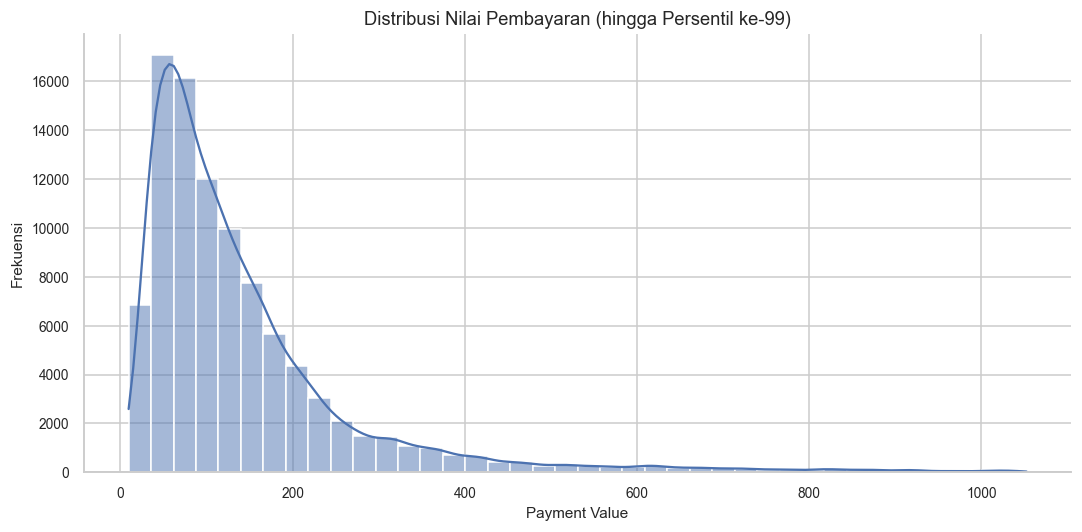

In [11]:
payment_limit_99 = main_df["payment_value"].quantile(0.99)
payment_for_hist_df = main_df[main_df["payment_value"] <= payment_limit_99]

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data=payment_for_hist_df,
    x="payment_value",
    bins=40,
    kde=True,
    color="#4C72B0",
    ax=ax
)
ax.set_title("Distribusi Nilai Pembayaran (hingga Persentil ke-99)")
ax.set_xlabel("Payment Value")
ax.set_ylabel("Frekuensi")
sns.despine()
plt.tight_layout()
display(fig)
plt.close(fig)


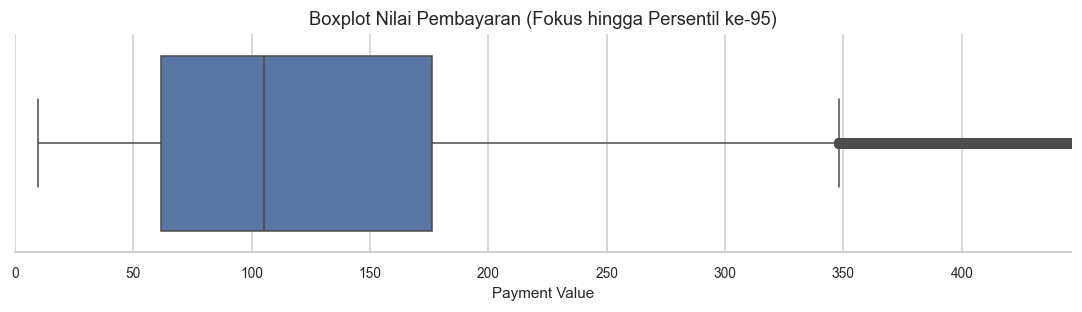

In [12]:
payment_limit_95 = main_df["payment_value"].quantile(0.95)

fig, ax = plt.subplots(figsize=(10, 3))
sns.boxplot(data=main_df, x="payment_value", color="#4C72B0", ax=ax)
ax.set_title("Boxplot Nilai Pembayaran (Fokus hingga Persentil ke-95)")
ax.set_xlabel("Payment Value")
ax.set_xlim(0, payment_limit_95)
sns.despine(left=True)
plt.tight_layout()
display(fig)
plt.close(fig)


In [13]:
def format_angka(value):
    return f"{int(value):,}".replace(",", ".")

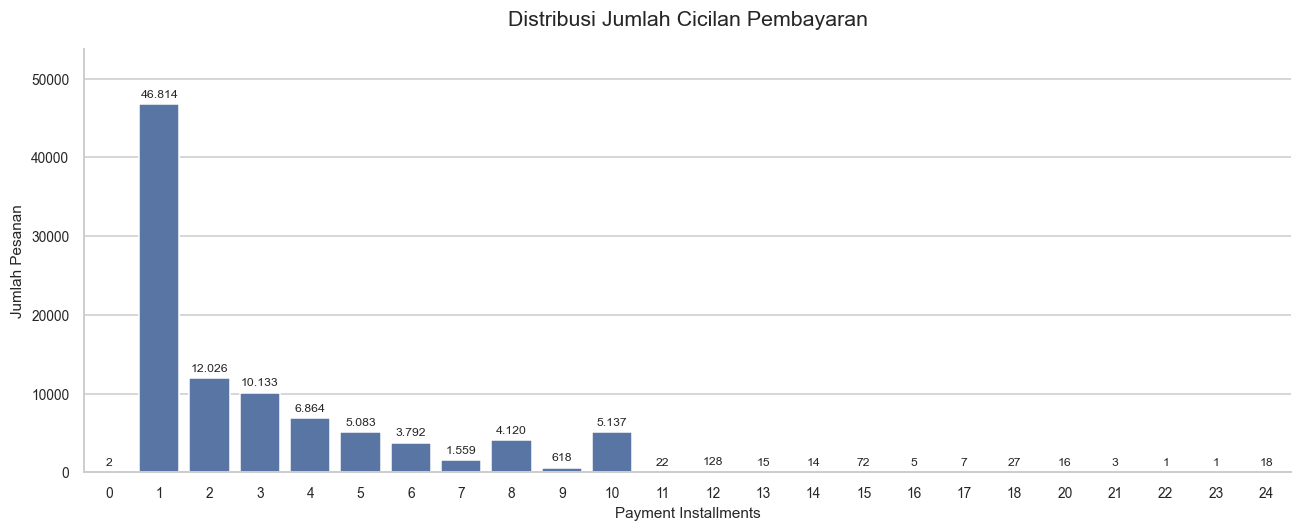

In [14]:
installment_count_df = main_df["payment_installments"].value_counts().sort_index().reset_index()
installment_count_df.columns = ["payment_installments", "order_count"]
installment_count_df["payment_installments"] = installment_count_df["payment_installments"].astype(int).astype(str)

fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(
    data=installment_count_df,
    x="payment_installments",
    y="order_count",
    color="#4C72B0",
    ax=ax
)

ax.set_title("Distribusi Jumlah Cicilan Pembayaran", fontsize=14, pad=15)
ax.set_xlabel("Payment Installments")
ax.set_ylabel("Jumlah Pesanan")
ax.tick_params(axis="x", rotation=0)

# Menambahkan angka pada setiap bar
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[format_angka(v) for v in container.datavalues],
        padding=3,
        fontsize=8
    )

# Memberi ruang agar label tidak terpotong
ax.set_ylim(0, installment_count_df["order_count"].max() * 1.15)

sns.despine()
plt.tight_layout()
display(fig)
plt.close(fig)


**Insight:**
- Distribusi `payment_value` cenderung tidak simetris atau left-skewed karena sebagian besar transaksi berada pada nilai kecil (50) hingga menengah (150), sementara beberapa transaksi memiliki nilai yang jauh lebih besar.
- Boxplot membantu menunjukkan adanya nilai ekstrem pada pembayaran, sehingga median dan kuartil juga perlu diperhatikan selain rata-rata karena nilai rata-rata sangat dipengaruhi nilai-nilai ekstrem.
- Distribusi `payment_installments` menunjukkan bagaimana pelanggan memilih jumlah cicilan dalam transaksi e-commerce dengan transaksi terbanyak menggunakan 1 cicilan, disusul oleh sebagian besar menggunakan 2-3 cicilan, tetapi ada juga yang menggunakan hingga 24 cicilan yang diduga sebagai alasan nilai pembayaran yang sangat besar pada beberapa transaksi.

### Explore Kategorikal dan Numerikal

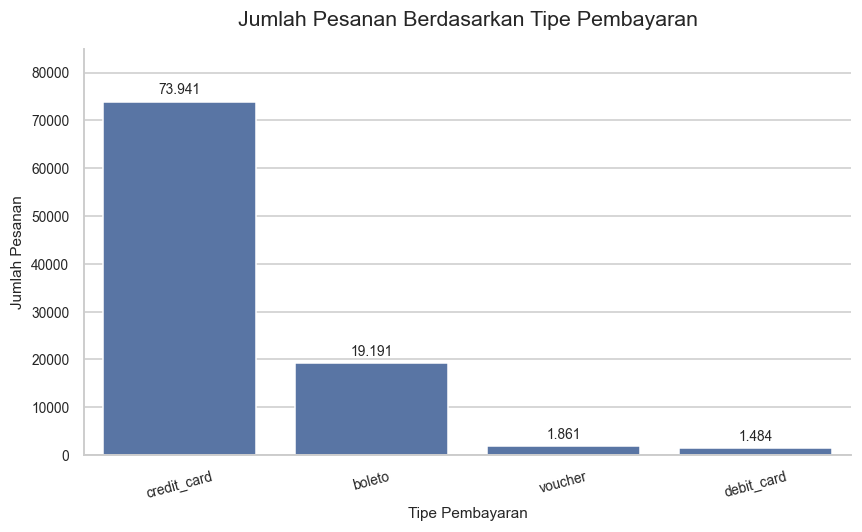

In [15]:
payment_type_count = main_df["payment_type"].value_counts().reset_index()
payment_type_count.columns = ["payment_type", "order_count"]

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=payment_type_count,
    x="payment_type",
    y="order_count",
    color="#4C72B0",
    ax=ax
)

ax.set_title("Jumlah Pesanan Berdasarkan Tipe Pembayaran", fontsize=14, pad=15)
ax.set_xlabel("Tipe Pembayaran")
ax.set_ylabel("Jumlah Pesanan")
ax.tick_params(axis="x", rotation=15)

# Menambahkan angka pada setiap bar
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[format_angka(v) for v in container.datavalues],
        padding=3,
        fontsize=9
    )

ax.set_ylim(0, payment_type_count["order_count"].max() * 1.15)

sns.despine()
plt.tight_layout()
display(fig)
plt.close(fig)


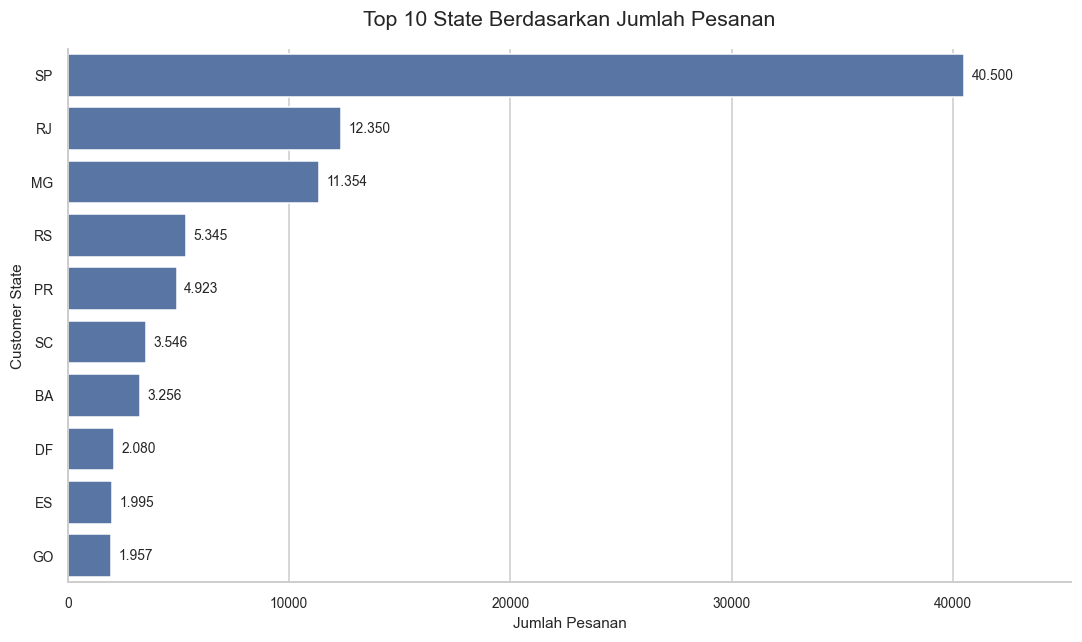

In [16]:
top_state_df = main_df.groupby("customer_state", as_index=False).agg(
    order_count=("order_id", "nunique")
)

top_state_df = top_state_df.sort_values("order_count", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=top_state_df,
    x="order_count",
    y="customer_state",
    color="#4C72B0",
    ax=ax
)

ax.set_title("Top 10 State Berdasarkan Jumlah Pesanan", fontsize=14, pad=15)
ax.set_xlabel("Jumlah Pesanan")
ax.set_ylabel("Customer State")

# Menambahkan angka di ujung bar horizontal
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[format_angka(v) for v in container.datavalues],
        padding=5,
        fontsize=9
    )

# Memberi ruang di kanan agar label tidak terpotong
ax.set_xlim(0, top_state_df["order_count"].max() * 1.12)

sns.despine()
plt.tight_layout()
display(fig)
plt.close(fig)


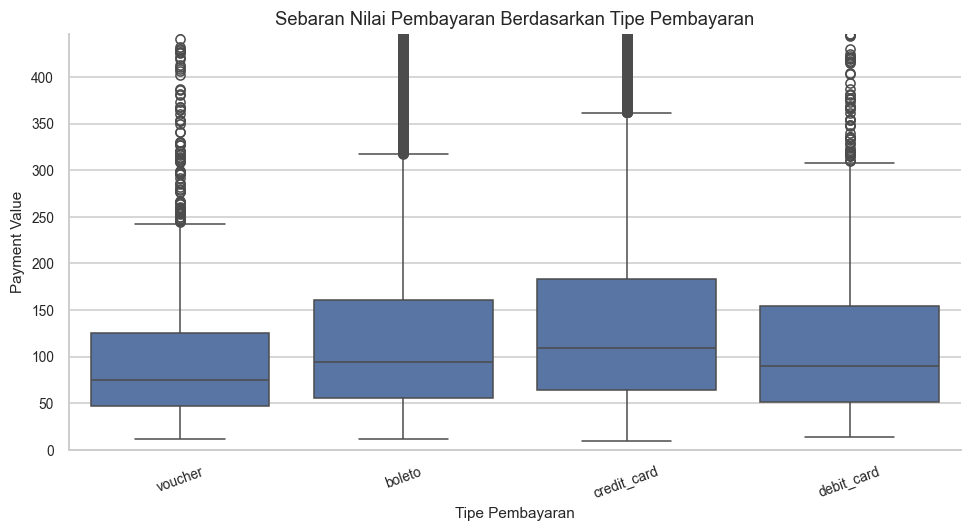

In [17]:
payment_limit_95 = main_df["payment_value"].quantile(0.95)

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=main_df, x="payment_type", y="payment_value", color="#4C72B0", ax=ax)
ax.set_title("Sebaran Nilai Pembayaran Berdasarkan Tipe Pembayaran")
ax.set_xlabel("Tipe Pembayaran")
ax.set_ylabel("Payment Value")
ax.set_ylim(0, payment_limit_95)
ax.tick_params(axis="x", rotation=20)
sns.despine()
plt.tight_layout()
display(fig)
plt.close(fig)


In [37]:
payment_type_summary_df = main_df.groupby("payment_type", as_index=False).agg(
    order_count=("order_id", "nunique"),
    avg_payment=("payment_value", "mean"),
    median_payment=("payment_value", "median"),
    total_revenue=("payment_value", "sum")
).sort_values("total_revenue", ascending=False)

payment_type_summary_df[["avg_payment", "median_payment"]] = payment_type_summary_df[
    ["avg_payment", "median_payment"]
].round(2)

display(payment_type_summary_df)

,payment_type,order_count,avg_payment,median_payment,total_revenue
1,credit_card,73941,165.44,108.86,12232755.27
0,boleto,19191,144.33,93.78,2769932.58
3,voucher,1861,113.60,74.67,211402.80
2,debit_card,1484,140.41,89.62,208371.12


**Insight:**
- Tipe pembayaran `credit_card` mendominasi jumlah transaksi, disusul oleh sebagian besar menggunakan `boleto`, sehingga metode pembayaran dapat menjadi salah satu faktor penting dalam pengalaman belanja pelanggan. 
- State São Paulo (SP) mendominasi jumlah transaksi, disusul oleh sebagian besar dari Rio de Janeiro (RJ) dan Minas Gerais (MG), yang menunjukkan adanya konsentrasi pelanggan pada wilayah tertentu.
- Perbandingan `payment_value` berdasarkan `payment_type` membantu melihat apakah ada perbedaan karakteristik transaksi pada setiap metode pembayaran. Tipe pembayaran `credit_card` memiliki nilai pembayaran yang  tertinggi, menunjukkan bahwa pelanggan yang menggunakan kartu kredit cenderung melakukan pembelian dengan nilai lebih besar. Sedangkan tipe pembayaran `voucher` memiliki nilai pembayaran terendah, menunjukkan bahwa pelanggan yang menggunakan voucher cenderung melakukan pembelian dengan nilai lebih kecil. Hal ini bisa menjadi insight penting dalam strategi pemasaran dan penawaran promosi berdasarkan metode pembayaran yang digunakan pelanggan.

### Explore Multivariate: Korelasi dan Hubungan Antar Variabel

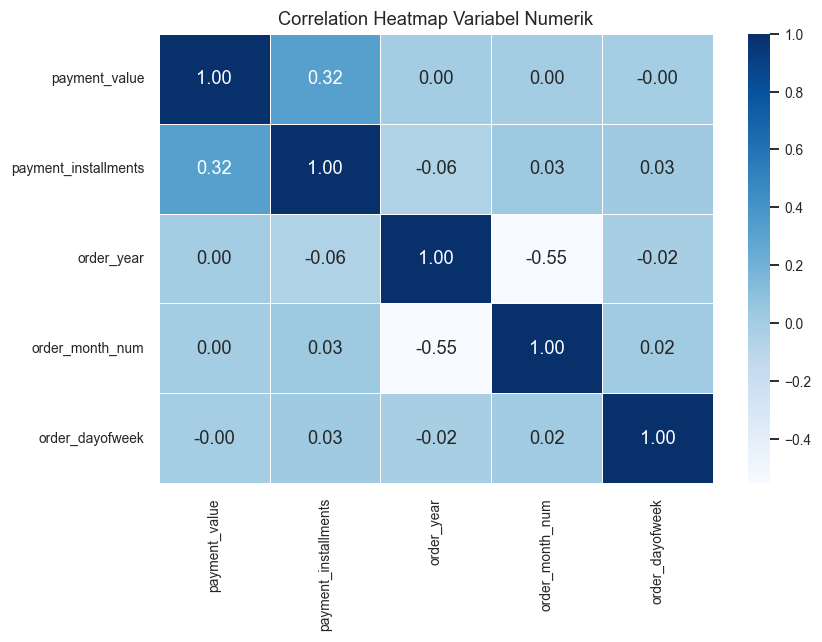

In [19]:
numerical_columns = [
    "payment_value",
    "payment_installments",
    "order_year",
    "order_month_num",
    "order_dayofweek"
]

corr_df = main_df[numerical_columns].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, cmap="Blues", fmt=".2f", linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap Variabel Numerik")
plt.tight_layout()
display(fig)
plt.close(fig)


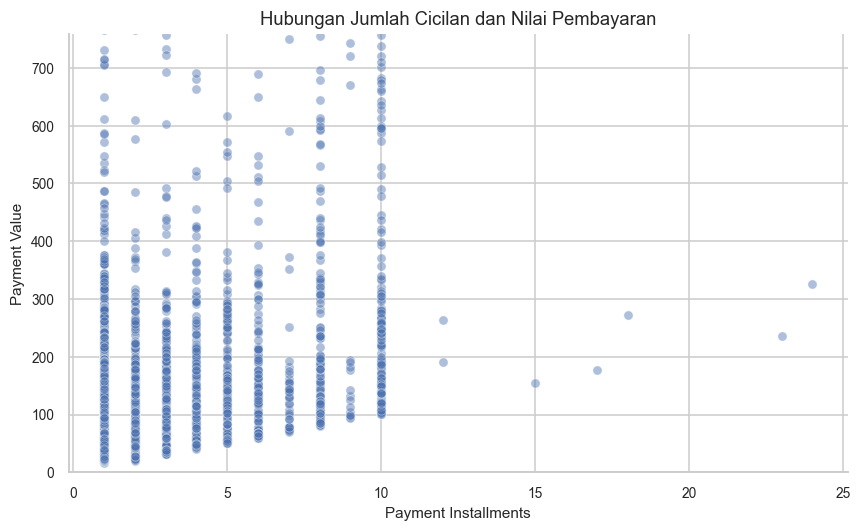

In [20]:
sample_df = main_df.sample(n=min(3000, len(main_df)), random_state=42)

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=sample_df,
    x="payment_installments",
    y="payment_value",
    alpha=0.45,
    color="#4C72B0",
    ax=ax
)
ax.set_title("Hubungan Jumlah Cicilan dan Nilai Pembayaran")
ax.set_xlabel("Payment Installments")
ax.set_ylabel("Payment Value")
ax.set_ylim(0, main_df["payment_value"].quantile(0.98))
sns.despine()
plt.tight_layout()
display(fig)
plt.close(fig)


**Insight:**
- Heatmap korelasi digunakan untuk melihat hubungan antarvariabel numerik secara ringkas. Korelasi positif antara `payment_value` dan `payment_installments` menunjukkan bahwa transaksi dengan nilai pembayaran yang lebih besar cenderung memiliki jumlah cicilan yang lebih banyak meskipun hubungannya lemah (0.32). Sedangkan sisa hubungan antarvariabel numerik lainnya menunjukkan korelasi yang sangat lemah atau tidak ada korelasi sama sekali.
- Scatter plot antara `payment_installments` dan `payment_value` membantu mengamati apakah nilai pembayaran yang lebih besar cenderung berkaitan dengan jumlah cicilan yang lebih tinggi. Scatter plot menunjukkan bahwa sebagian besar transaksi dengan nilai pembayaran kecil hingga menengah memiliki jumlah cicilan 1-3. Lalu sebagian besar transaksi lainnya terdapat pada jumlah cicilan 4-10. Tetapi ada beberapa transaksi dengan nilai pembayaran yang sangat besar yang memiliki jumlah cicilan hingga 24, yang mendukung hasil korelasi positif meskipun lemah.
- EDA multivariate ini melengkapi analisis univariate karena melihat hubungan antarvariabel, bukan hanya distribusi masing-masing variabel. 

### Explore Pola Bulanan Awal

In [38]:
monthly_sales_df = main_df.groupby(["order_month", "order_month_date"], as_index=False).agg(
    order_count=("order_id", "nunique"),
    total_revenue=("payment_value", "sum"),
    avg_revenue_per_order=("payment_value", "mean")
).sort_values("order_month_date")

monthly_sales_df["avg_revenue_per_order"] = monthly_sales_df["avg_revenue_per_order"].round(2)

display(monthly_sales_df.head())
display(monthly_sales_df.tail())

,order_month,order_month_date,order_count,total_revenue,avg_revenue_per_order
0,2016-10,2016-10-01,265,46566.71,175.72
1,2016-12,2016-12-01,1,19.62,19.62
2,2017-01,2017-01-01,750,127545.67,170.06
3,2017-02,2017-02-01,1653,271298.65,164.13
4,2017-03,2017-03-01,2546,414369.39,162.75


,order_month,order_month_date,order_count,total_revenue,avg_revenue_per_order
17,2018-04,2018-04-01,6798,1132933.95,166.66
18,2018-05,2018-05-01,6749,1128836.69,167.26
19,2018-06,2018-06-01,6099,1012090.68,165.94
20,2018-07,2018-07-01,6159,1027903.86,166.89
21,2018-08,2018-08-01,6351,985414.28,155.16


In [40]:
print("Bulan dengan jumlah pesanan tertinggi:")
display(
    monthly_sales_df.sort_values("order_count", ascending=False)
    .head(5)
    .round({"avg_revenue_per_order": 2})
)

print("Bulan dengan total pendapatan tertinggi:")
display(
    monthly_sales_df.sort_values("total_revenue", ascending=False)
    .head(5)
    .round({"avg_revenue_per_order": 2})
)

Bulan dengan jumlah pesanan tertinggi:


,order_month,order_month_date,order_count,total_revenue,avg_revenue_per_order
12,2017-11,2017-11-01,7289,1153528.05,158.26
14,2018-01,2018-01-01,7069,1078606.86,152.58
16,2018-03,2018-03-01,7003,1120678.00,160.03
17,2018-04,2018-04-01,6798,1132933.95,166.66
18,2018-05,2018-05-01,6749,1128836.69,167.26


Bulan dengan total pendapatan tertinggi:


,order_month,order_month_date,order_count,total_revenue,avg_revenue_per_order
12,2017-11,2017-11-01,7289,1153528.05,158.26
17,2018-04,2018-04-01,6798,1132933.95,166.66
18,2018-05,2018-05-01,6749,1128836.69,167.26
16,2018-03,2018-03-01,7003,1120678.00,160.03
14,2018-01,2018-01-01,7069,1078606.86,152.58


**Insight:**
- Agregasi bulanan digunakan sebagai eksplorasi awal sebelum masuk ke visualisasi dan explanatory analysis untuk pertanyaan bisnis pertama.
- Tabel ini menunjukkan perubahan jumlah pesanan, total pendapatan, dan rata-rata pendapatan per order dari bulan ke bulan. 
- Bulan dengan jumlah pesanan tertinggi dan bulan dengan pendapatan tertinggi dapat langsung dibandingkan untuk melihat apakah keduanya terjadi pada periode yang sama. Bulan dengan jumlah pesanan tertinggi dan pendapatan tertinggi terjadi bulan November 2017, yang menunjukkan bahwa pada bulan tersebut terjadi peningkatan penjualan yang signifikan baik dari segi jumlah pesanan maupun total pendapatan. Hal ini bisa menjadi insight penting dalam menentukan periode penjualan terbaik untuk strategi pemasaran dan promosi di masa mendatang. 

## Visualization & Explanatory Analysis

### Pertanyaan 1: Tren Performa Penjualan Bulanan

In [23]:
peak_order_month = monthly_sales_df.sort_values("order_count", ascending=False).iloc[0]
peak_revenue_month = monthly_sales_df.sort_values("total_revenue", ascending=False).iloc[0]

print("Bulan dengan jumlah pesanan tertinggi:", peak_order_month["order_month"], "=", int(peak_order_month["order_count"]), "pesanan")
print("Bulan dengan total pendapatan tertinggi:", peak_revenue_month["order_month"], "=", round(peak_revenue_month["total_revenue"], 2))

Bulan dengan jumlah pesanan tertinggi: 2017-11 = 7289 pesanan
Bulan dengan total pendapatan tertinggi: 2017-11 = 1153528.05


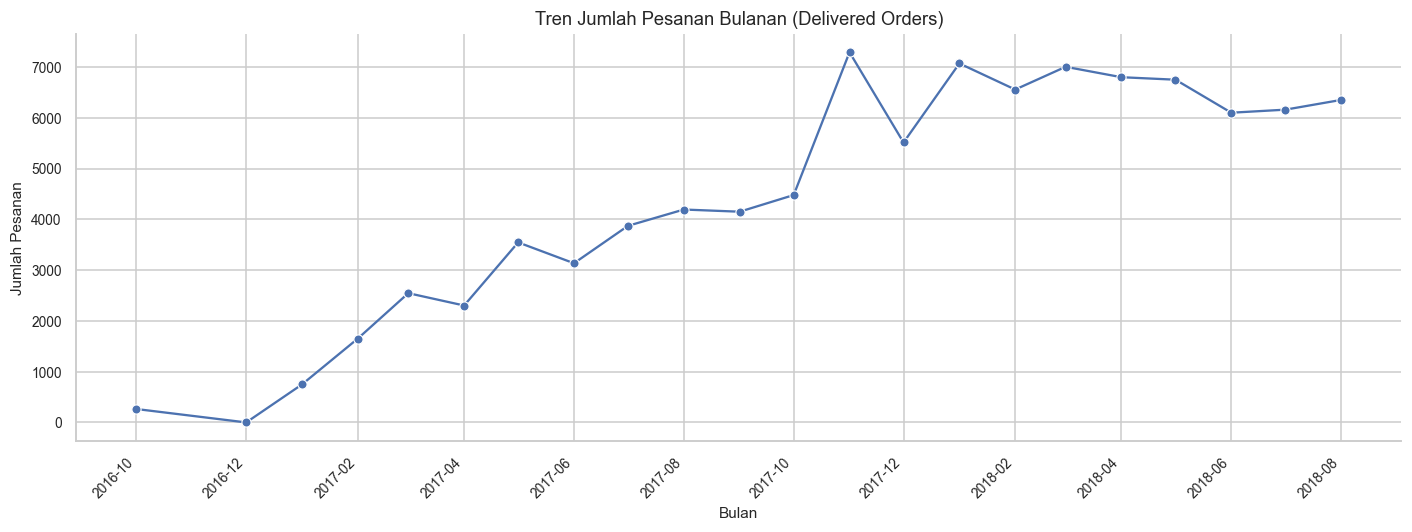

In [24]:
fig, ax = plt.subplots(figsize=(13, 5))
sns.lineplot(data=monthly_sales_df, x="order_month_date", y="order_count", marker="o", color="#4C72B0", ax=ax)
ax.set_title("Tren Jumlah Pesanan Bulanan (Delivered Orders)")
ax.set_xlabel("Bulan")
ax.set_ylabel("Jumlah Pesanan")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
sns.despine()
plt.tight_layout()
display(fig)
plt.close(fig)


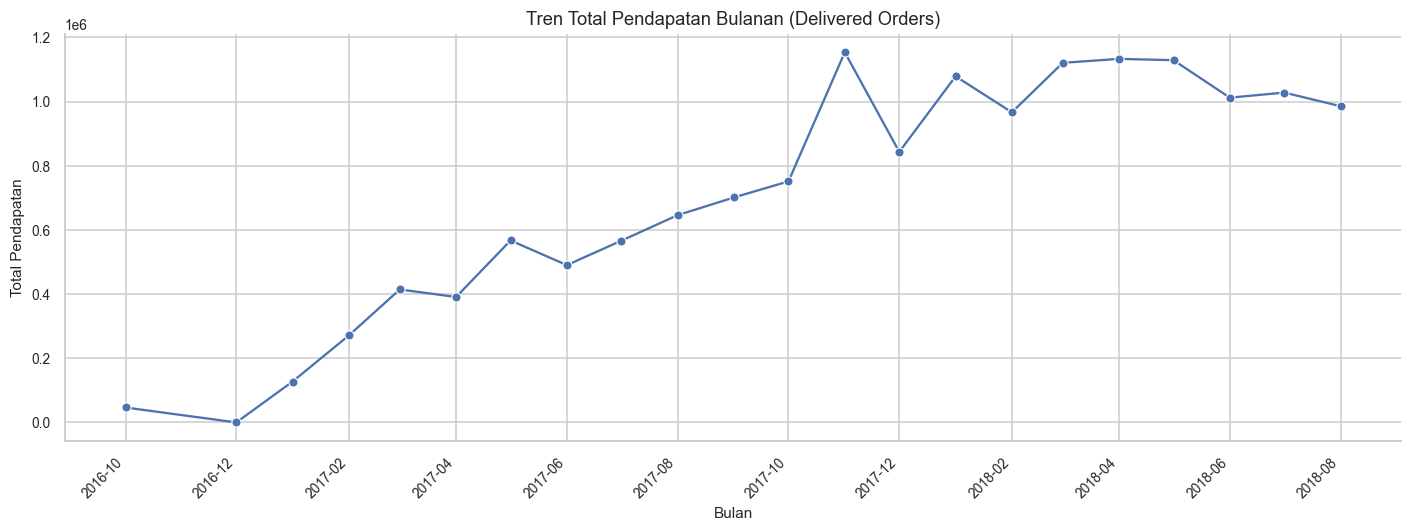

In [25]:
fig, ax = plt.subplots(figsize=(13, 5))
sns.lineplot(data=monthly_sales_df, x="order_month_date", y="total_revenue", marker="o", color="#4C72B0", ax=ax)
ax.set_title("Tren Total Pendapatan Bulanan (Delivered Orders)")
ax.set_xlabel("Bulan")
ax.set_ylabel("Total Pendapatan")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
sns.despine()
plt.tight_layout()
display(fig)
plt.close(fig)


**Insight Pertanyaan 1:**
- Selama periode Oktober 2016-Agustus 2018, tren jumlah pesanan dan total pendapatan bergerak naik-turun (fluktuatif) dari bulan ke bulan tetapi sama-sama menunjukkan tren positif.
- November 2017 menjadi bulan dengan performa penjualan tertinggi berdasarkan jumlah pesanan dan total pendapatan.
- Pola ini bisa menjadi insight bisnis dalam meninjau kembali aktivitas promosi, permintaan pasar, atau momentum belanja pada periode tersebut.

### Pertanyaan 2: Segmentasi Pelanggan Menggunakan RFM Analysis

In [26]:
snapshot_date = main_df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm_df = main_df.groupby("customer_unique_id", as_index=False).agg(
    last_order_date=("order_purchase_timestamp", "max"),
    frequency=("order_id", "nunique"),
    monetary=("payment_value", "sum")
)

rfm_df["recency"] = (snapshot_date - rfm_df["last_order_date"]).dt.days
rfm_df = rfm_df[["customer_unique_id", "recency", "frequency", "monetary", "last_order_date"]]

rfm_df.head()

,customer_unique_id,recency,frequency,monetary,last_order_date
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,2018-05-10 10:56:27
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,2018-05-07 11:11:27
2,0000f46a3911fa3c0805444483337064,537,1,86.22,2017-03-10 21:05:03
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2017-10-12 20:29:41
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2017-11-14 19:45:42


In [27]:
rfm_df["r_score"] = pd.qcut(rfm_df["recency"].rank(method="first"), 4, labels=[4, 3, 2, 1]).astype(int)
rfm_df["f_score"] = pd.qcut(rfm_df["frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm_df["m_score"] = pd.qcut(rfm_df["monetary"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)

rfm_df["rfm_score"] = (
    rfm_df["r_score"].astype(str) +
    rfm_df["f_score"].astype(str) +
    rfm_df["m_score"].astype(str)
)

def define_customer_segment(row):
    if row["r_score"] >= 3 and row["f_score"] >= 3 and row["m_score"] >= 3:
        return "Loyal/VIP Customer"
    elif row["r_score"] >= 3 and row["f_score"] <= 2:
        return "New Customer"
    elif row["r_score"] <= 2 and row["f_score"] >= 3 and row["m_score"] >= 3:
        return "At Risk High Value"
    elif row["m_score"] >= 3:
        return "Potential Customer"
    else:
        return "Regular Customer"

rfm_df["customer_segment"] = rfm_df.apply(define_customer_segment, axis=1)

display(rfm_df.head())

,customer_unique_id,recency,frequency,monetary,last_order_date,r_score,f_score,m_score,rfm_score,customer_segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,2018-05-10 10:56:27,4,1,3,413,New Customer
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,2018-05-07 11:11:27,3,1,1,311,New Customer
2,0000f46a3911fa3c0805444483337064,537,1,86.22,2017-03-10 21:05:03,1,1,2,112,Regular Customer
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2017-10-12 20:29:41,2,1,1,211,Regular Customer
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2017-11-14 19:45:42,2,1,4,214,Potential Customer


In [42]:
segment_summary_df = rfm_df.groupby("customer_segment", as_index=False).agg(
    customer_count=("customer_unique_id", "nunique"),
    avg_recency=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
    total_monetary=("monetary", "sum")
).sort_values("avg_monetary", ascending=False)

segment_summary_df = segment_summary_df.round(2)

most_valuable_segment = segment_summary_df.iloc[0]

print("Segmen pelanggan dengan rata-rata monetary tertinggi:", most_valuable_segment["customer_segment"])
display(segment_summary_df)

Segmen pelanggan dengan rata-rata monetary tertinggi: Loyal/VIP Customer


,customer_segment,customer_count,avg_recency,avg_frequency,avg_monetary,total_monetary
1,Loyal/VIP Customer,12235,112.14,1.13,271.96,3327413.90
0,At Risk High Value,11600,363.39,1.10,269.35,3124484.82
3,Potential Customer,11230,363.91,1.00,265.96,2986734.53
2,New Customer,23324,111.91,1.00,160.94,3753742.01
4,Regular Customer,34968,283.94,1.01,63.78,2230086.51


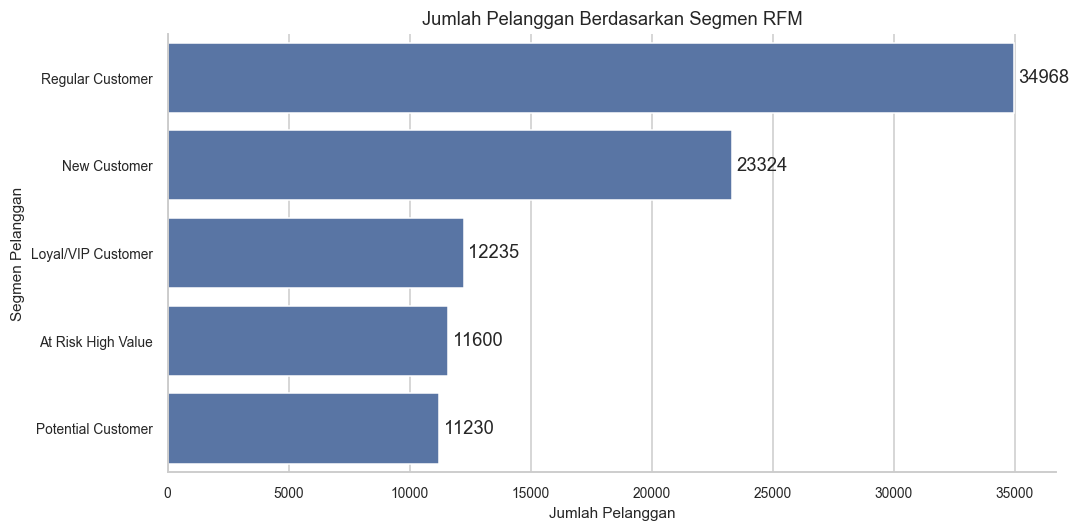

In [29]:
segment_count_df = segment_summary_df.sort_values("customer_count", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=segment_count_df, x="customer_count", y="customer_segment", color="#4C72B0", ax=ax)
ax.set_title("Jumlah Pelanggan Berdasarkan Segmen RFM")
ax.set_xlabel("Jumlah Pelanggan")
ax.set_ylabel("Segmen Pelanggan")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)
sns.despine()
plt.tight_layout()
display(fig)
plt.close(fig)


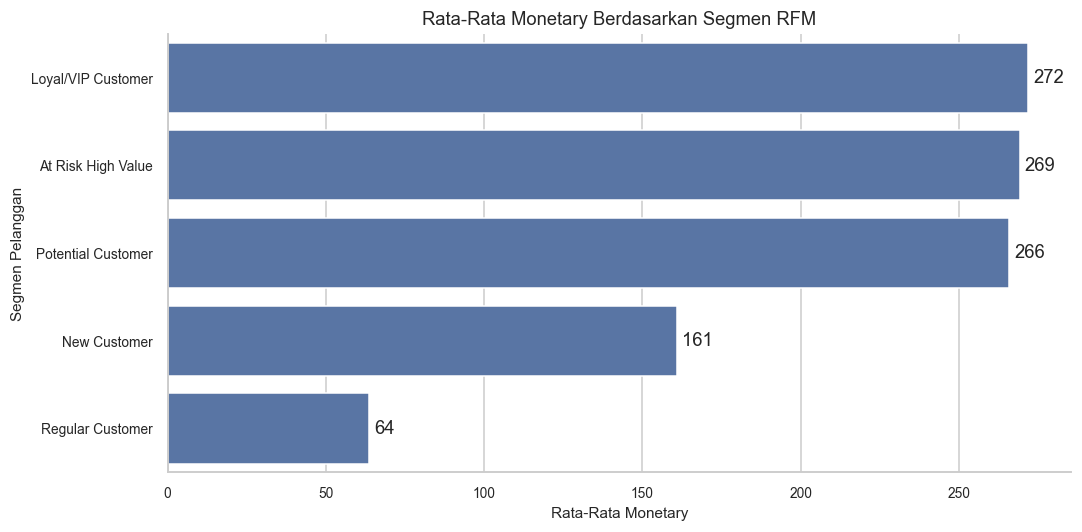

In [30]:
segment_monetary_df = segment_summary_df.sort_values("avg_monetary", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=segment_monetary_df, x="avg_monetary", y="customer_segment", color="#4C72B0", ax=ax)
ax.set_title("Rata-Rata Monetary Berdasarkan Segmen RFM")
ax.set_xlabel("Rata-Rata Monetary")
ax.set_ylabel("Segmen Pelanggan")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)
sns.despine()
plt.tight_layout()
display(fig)
plt.close(fig)


**Insight Pertanyaan 2:**
- RFM analysis membagi pelanggan berdasarkan tiga aspek, yaitu seberapa baru pelanggan bertransaksi (recency), seberapa sering pelanggan membeli (frequency), dan seberapa besar nilai transaksinya (monetary). 
- Segmen dengan rata-rata monetary tertinggi dapat dipandang sebagai kelompok pelanggan paling bernilai bagi bisnis. Segmen tersebut adalah loyal/VIP customer yang memiliki recency rendah (baru bertransaksi), frequency tertinggi (paling sering membeli), dan monetary tertinggi (nilai transaksi terbesar) meskipun bukan merupakan segmen dengan jumlah customer terbanyak.
- Segmen dengan jumlah customer terbanyak adalah regular customer yang memiliki recency sedang, frequency rendah, dan monetary terendah.
- Segmentasi ini membantu bisnis menentukan prioritas strategi, seperti mempertahankan pelanggan bernilai tinggi dan mengaktifkan kembali pelanggan yang berisiko menurun aktivitasnya.

## Analisis Lanjutan

In [43]:
print("Rangkuman hasil RFM Analysis:")
display(segment_summary_df.round(2))

print("Top 5 pelanggan berdasarkan monetary:")
display(
    rfm_df.sort_values("monetary", ascending=False)
    .head(5)
    .round(2)
)

Rangkuman hasil RFM Analysis:


,customer_segment,customer_count,avg_recency,avg_frequency,avg_monetary,total_monetary
1,Loyal/VIP Customer,12235,112.14,1.13,271.96,3327413.90
0,At Risk High Value,11600,363.39,1.10,269.35,3124484.82
3,Potential Customer,11230,363.91,1.00,265.96,2986734.53
2,New Customer,23324,111.91,1.00,160.94,3753742.01
4,Regular Customer,34968,283.94,1.01,63.78,2230086.51


Top 5 pelanggan berdasarkan monetary:


C:\Users\Admin\AppData\Local\Temp\ipykernel_15960\3189549512.py:8: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(2)


,customer_unique_id,recency,frequency,monetary,last_order_date,r_score,f_score,m_score,rfm_score,customer_segment
3724,0a0a92112bd4c708ca5fde585afaa872,334,1,13664.08,2017-09-29 15:24:52,2,1,4,214,Potential Customer
79635,da122df9eeddfedc1dc1f5349a1a690c,515,2,7571.63,2017-04-01 15:58:41,1,4,4,144,At Risk High Value
43168,763c8b1c9c68a0229c42c9fc6f662b93,46,1,7274.88,2018-07-15 14:49:44,4,2,4,424,New Customer
80462,dc4802a71eae9be1dd28f5d788ceb526,563,1,6929.31,2017-02-12 20:37:36,1,4,4,144,At Risk High Value
25436,459bef486812aa25204be022145caa62,35,1,6922.21,2018-07-25 18:10:17,4,2,4,424,New Customer


**Insight:**
- Analisis lanjutan yang digunakan adalah RFM Analysis dengan pendekatan manual grouping.
- RFM relevan dengan dataset Olist karena data memiliki informasi pelanggan, waktu transaksi, dan nilai pembayaran.
- Hasil segmentasinya adalah segmen loyal/VIP customer yang memiliki recency rendah, frequency tertinggi, dan monetary tertinggi sebagai segmen pelanggan paling bernilai bagi bisnis. Sedangkan segmen regular customer yang memiliki recency sedang, frequency rendah, dan monetary terendah sebagai segmen pelanggan dengan jumlah terbanyak tetapi nilai transaksi yang lebih kecil.
- Secara individu, customer dengan nilai monetary tertinggi memiliki nilai pembayaran sebesar 13664.08 dengan segmennya 'Potential Customer', yang menunjukkan bahwa pelanggan tersebut melakukan pembelian dengan nilai yang sangat besar dibandingkan dengan rata-rata pelanggan lainnya. Hal ini bisa menjadi insight penting dalam strategi pemasaran dan penawaran khusus untuk pelanggan bernilai tinggi.
- Hasil segmentasi bisa dipakai sebagai dasar rekomendasi bisnis, terutama untuk retensi pelanggan dan pengelolaan campaign.

## Conclusion & Recommendation

In [32]:
print("Conclusion Pertanyaan 1")
print(f"Bulan dengan jumlah pesanan tertinggi adalah {peak_order_month['order_month']} dengan {int(peak_order_month['order_count'])} pesanan.")
print(f"Bulan dengan total pendapatan tertinggi adalah {peak_revenue_month['order_month']} dengan total pendapatan {peak_revenue_month['total_revenue']:.2f}.")

print("\nConclusion Pertanyaan 2")
print(f"Segmen pelanggan paling berharga berdasarkan rata-rata monetary adalah {most_valuable_segment['customer_segment']} dengan rata-rata monetary {most_valuable_segment['avg_monetary']:.2f}.")

Conclusion Pertanyaan 1
Bulan dengan jumlah pesanan tertinggi adalah 2017-11 dengan 7289 pesanan.
Bulan dengan total pendapatan tertinggi adalah 2017-11 dengan total pendapatan 1153528.05.

Conclusion Pertanyaan 2
Segmen pelanggan paling berharga berdasarkan rata-rata monetary adalah Loyal/VIP Customer dengan rata-rata monetary 271.96.


- **Conclusion pertanyaan 1:** Selama periode Oktober 2016 sampai Agustus 2018, performa penjualan Olist menunjukkan fluktuasi dengan tren positif dari bulan ke bulan. Bulan dengan jumlah pesanan dan total pendapatan tertinggi adalah November 2017.
- **Conclusion pertanyaan 2:** Berdasarkan RFM analysis, segmen pelanggan paling berharga adalah segmen dengan rata-rata monetary tertinggi yaitu loyal/VIP customer. Segmen ini perlu menjadi prioritas karena memberikan kontribusi nilai transaksi yang lebih besar dibandingkan segmen lain.

**Rekomendasi Action Item:**
- Mengevaluasi strategi penjualan pada bulan dengan performa terbaik agar pola kesuksesannya bisa dipelajari dan diterapkan pada periode lain.
- Mengoptimalkan promosi pada periode yang cenderung memiliki penjualan rendah untuk menjaga stabilitas pendapatan bulanan.
- Memberikan program retensi atau loyalty benefit kepada pelanggan pada segmen monetary bernilai tinggi untuk menjaga frequency pembelian.
- Menyiapkan campaign reaktivasi untuk pelanggan yang sudah lama tidak bertransaksi agar peluang pembelian ulang meningkat dan meningkatkan recency pembelian.